In [12]:


# ============================================================================
# PART 1: Installation and Setup
# ============================================================================

print("Installing required packages...")
print("This may take a few minutes...")

!pip install deoldify
!pip install opencv-python pillow numpy matplotlib scikit-image

import os
import urllib.request
from pathlib import Path

def download_model_weights():
    """Download DeOldify model"""
    
    models_dir = Path('./models')
    models_dir.mkdir(exist_ok=True)
    
    models = {
        'ColorizeArtistic_gen.pth': 'https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth',
        'ColorizeStable_gen.pth': 'https://www.dropbox.com/s/usf7uifrctqw57u/ColorizeStable_gen.pth?dl=1'
    }
    
    for model_name, url in models.items():
        model_path = models_dir / model_name
        
        if model_path.exists():
            print(f"✓ {model_name} already exists")
        else:
            print(f"⬇ Downloading {model_name}...")
            print(f"   This may take a few minutes (file size ~200MB)...")
            try:
                urllib.request.urlretrieve(url, model_path)
                print(f"✓ {model_name} downloaded successfully")
            except Exception as e:
                print(f"✗ Failed to download {model_name}: {e}")
                print(f"   Please download manually from: {url}")
                print(f"   Save to: {model_path}")
    
    print("\n✓ Model setup complete!")

# Run the download
download_model_weights()

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from skimage import color
import warnings
warnings.filterwarnings('ignore')

import functools
import torch.serialization

print("Configuring PyTorch safe globals for DeOldify compatibility...")
try:
    # Import fastai components that need to be whitelisted
    from fastai.basic_train import Recorder
    from fastai.callbacks import Callback
    from fastai.torch_core import flatten_check
    
    torch.serialization.add_safe_globals([
        functools.partial,
        Recorder,
        Callback,
        flatten_check
    ])
    print("✓ Safe globals configured")
except Exception as e:
    print(f"Note: Some safe globals may not be needed: {e}")

import torch

if not hasattr(torch.load, '_deoldify_patched'):
    _original_load = torch.load
    
    def _patched_load(*args, **kwargs):
        """Patched torch.load that uses weights_only=False for compatibility"""
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)
    
    _patched_load._deoldify_patched = True
    torch.load = _patched_load
    print("✓ PyTorch load function patched for compatibility")
else:
    print("✓ PyTorch load function already patched")

# DeOldify imports
from deoldify import device
from deoldify.device_id import DeviceId
from deoldify.visualize import get_image_colorizer

print("✓ Imports successful!")

# ============================================================================
# PART 2: HSV Color Adjustment Functions
# ============================================================================

class HSVColorAdjuster:
    """Advanced HSV-based color adjustment and enhancement"""
    
    def __init__(self):
        # Define typical hue ranges for common objects (in OpenCV 0-180 scale)
        self.object_hues = {
            'sky': (90, 130),       # Blue
            'grass': (35, 85),      # Green
            'tree': (35, 85),       # Green
            'foliage': (35, 85),    # Green
            'skin': (0, 20),        # Orange-red
            'water': (90, 130),     # Blue
            'ocean': (90, 130),     # Blue
            'sand': (10, 30),       # Yellow-orange
            'building': None,       # Keep original
            'road': None,           # Keep original
        }
        
        self.saturation_boosts = {
            'sky': 1.2,
            'grass': 1.3,
            'tree': 1.3,
            'water': 1.25,
            'foliage': 1.3,
        }
    
    def analyze_color_distribution(self, img_rgb):
        """Analyze the color distribution of the image"""
        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        
        # Get dominant hues
        hue_hist, _ = np.histogram(img_hsv[:, :, 0].flatten(), bins=180, range=(0, 180))
        dominant_hues = np.argsort(hue_hist)[-5:]  # Top 5 hues
        
        # Get average saturation
        avg_saturation = np.mean(img_hsv[:, :, 1])
        
        return {
            'dominant_hues': dominant_hues,
            'avg_saturation': avg_saturation,
            'hsv': img_hsv
        }
    
    def adjust_saturation(self, img_hsv, factor=1.2, mask=None):
        """Enhance or reduce saturation"""
        if mask is not None:
            img_hsv[:, :, 1][mask] = np.clip(img_hsv[:, :, 1][mask] * factor, 0, 255)
        else:
            img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * factor, 0, 255)
        return img_hsv
    
    def adjust_value(self, img_hsv, factor=1.1, mask=None):
        """Adjust brightness/value"""
        if mask is not None:
            img_hsv[:, :, 2][mask] = np.clip(img_hsv[:, :, 2][mask] * factor, 0, 255)
        else:
            img_hsv[:, :, 2] = np.clip(img_hsv[:, :, 2] * factor, 0, 255)
        return img_hsv
    
    def detect_sky_region(self, img_hsv):
        """Simple sky detection based on position and color"""
        h, w = img_hsv.shape[:2]
        
        # Sky is typically in upper portion and blue
        upper_region = img_hsv[:h//3, :, :]
        
        # Blue hue range (90-130 in OpenCV)
        sky_mask = np.zeros((h, w), dtype=bool)
        sky_mask[:h//3, :] = (upper_region[:, :, 0] >= 90) & (upper_region[:, :, 0] <= 130)
        
        return sky_mask
    
    def detect_green_region(self, img_hsv):
        """Detect green regions (grass, trees, foliage)"""
        # Green hue range (35-85 in OpenCV)
        green_mask = (img_hsv[:, :, 0] >= 35) & (img_hsv[:, :, 0] <= 85)
        
        # Must have reasonable saturation
        green_mask &= (img_hsv[:, :, 1] > 30)
        
        return green_mask
    
    def enhance_specific_regions(self, img_rgb):
        """Enhance specific color regions intelligently"""
        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        
        # Detect and enhance sky
        sky_mask = self.detect_sky_region(img_hsv)
        if np.any(sky_mask):
            img_hsv = self.adjust_saturation(img_hsv, factor=1.25, mask=sky_mask)
        
        # Detect and enhance greenery
        green_mask = self.detect_green_region(img_hsv)
        if np.any(green_mask):
            img_hsv = self.adjust_saturation(img_hsv, factor=1.3, mask=green_mask)
        
        return img_hsv
    
    def color_temperature_adjust(self, img_hsv, temperature=0):
        """
        Adjust color temperature
        temperature: -50 (cooler/blue) to +50 (warmer/orange)
        """
        if temperature != 0:
            # Shift hue slightly
            shift = temperature / 10.0
            img_hsv[:, :, 0] = np.clip(img_hsv[:, :, 0] + shift, 0, 180)
        
        return img_hsv
    
    def enhance_colors(self, img_rgb, enhance_level='moderate'):
        """
        Apply overall color enhancement using HSV
        enhance_level: 'subtle', 'moderate', 'strong'
        """
        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        
        # Set enhancement parameters
        if enhance_level == 'subtle':
            sat_factor = 1.15
            val_factor = 1.05
        elif enhance_level == 'moderate':
            sat_factor = 1.25
            val_factor = 1.1
        else:  # strong
            sat_factor = 1.4
            val_factor = 1.15
        
        # Global adjustments
        img_hsv = self.adjust_saturation(img_hsv, factor=sat_factor)
        img_hsv = self.adjust_value(img_hsv, factor=val_factor)
        
        # Region-specific enhancements
        img_hsv = self.enhance_specific_regions(cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB))
        
        # Convert back to RGB
        img_rgb = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        
        return img_rgb
    
    def apply_custom_adjustment(self, img_rgb, hue_shift=0, sat_mult=1.0, val_mult=1.0):
        """Apply custom HSV adjustments"""
        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        
        if hue_shift != 0:
            img_hsv[:, :, 0] = np.clip(img_hsv[:, :, 0] + hue_shift, 0, 180)
        
        if sat_mult != 1.0:
            img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * sat_mult, 0, 255)
        
        if val_mult != 1.0:
            img_hsv[:, :, 2] = np.clip(img_hsv[:, :, 2] * val_mult, 0, 255)
        
        return cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

# ============================================================================
# PART 3: DeOldify Integration
# ============================================================================

class DeOldifyColorizer:
    """Wrapper for DeOldify with HSV enhancements"""
    
    def __init__(self, render_factor=35, artistic=True):
        """
        Initialize DeOldify colorizer
        
        render_factor: 10-45 (higher = better quality but slower, 35 is good default)
        artistic: True for more vibrant colors, False for more stable/realistic
        """
        # Set device
        device.set(device=DeviceId.GPU0 if torch.cuda.is_available() else DeviceId.CPU)
        
        # Initialize colorizer
        print(f"Initializing DeOldify ({'Artistic' if artistic else 'Stable'} mode)...")
        self.colorizer = get_image_colorizer(artistic=artistic)
        self.render_factor = render_factor
        self.hsv_adjuster = HSVColorAdjuster()
        
        print(f"Using device: {device.current()}")
        print("DeOldify ready!")
    
    def colorize_image(self, image_path, output_path=None):
        """
        Colorize a single image
        
        image_path: path to grayscale image
        output_path: where to save (optional)
        """
        print(f"\nColorizing: {image_path}")
        print(f"Render factor: {self.render_factor}")
        
        # Colorize with DeOldify
        result = self.colorizer.get_transformed_image(
            path=image_path,
            render_factor=self.render_factor,
            watermarked=False
        )
        
        if output_path:
            result.save(output_path)
            print(f"Saved to: {output_path}")
        
        return result
    
    def colorize_with_hsv(self, image_path, enhance_level='moderate', 
                          custom_adjustments=None, output_path=None):
        """
        Colorize image and apply HSV enhancements
        
        enhance_level: 'subtle', 'moderate', 'strong', or None
        custom_adjustments: dict with 'hue_shift', 'sat_mult', 'val_mult'
        """
        # Get DeOldify result
        colorized_pil = self.colorize_image(image_path)
        
        # Convert to numpy array
        colorized_np = np.array(colorized_pil)
        
        # Apply HSV enhancements
        if custom_adjustments:
            enhanced = self.hsv_adjuster.apply_custom_adjustment(
                colorized_np,
                hue_shift=custom_adjustments.get('hue_shift', 0),
                sat_mult=custom_adjustments.get('sat_mult', 1.0),
                val_mult=custom_adjustments.get('val_mult', 1.0)
            )
        elif enhance_level:
            enhanced = self.hsv_adjuster.enhance_colors(colorized_np, enhance_level)
        else:
            enhanced = colorized_np
        
        # Convert back to PIL
        enhanced_pil = Image.fromarray(enhanced)
        
        if output_path:
            enhanced_pil.save(output_path)
            print(f"Enhanced version saved to: {output_path}")
        
        return colorized_pil, enhanced_pil

# ============================================================================
# PART 4: Visualization Tools
# ============================================================================

def visualize_comparison(original_path, colorized, enhanced=None, figsize=(18, 6)):
    """Display original, colorized, and enhanced versions"""
    
    # Load original
    original = Image.open(original_path)
    
    if enhanced is not None:
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        images = [original, colorized, enhanced]
        titles = ['Original Grayscale', 'DeOldify Colorization', 'HSV Enhanced']
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        images = [original, colorized]
        titles = ['Original Grayscale', 'DeOldify Colorization']
        axes = [axes[0], axes[1]]
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

def show_hsv_analysis(image):
    """Visualize HSV channels separately"""
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Original
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original RGB')
    axes[0, 0].axis('off')
    
    # Hue
    axes[0, 1].imshow(img_hsv[:, :, 0], cmap='hsv')
    axes[0, 1].set_title('Hue Channel')
    axes[0, 1].axis('off')
    
    # Saturation
    axes[1, 0].imshow(img_hsv[:, :, 1], cmap='gray')
    axes[1, 0].set_title('Saturation Channel')
    axes[1, 0].axis('off')
    
    # Value
    axes[1, 1].imshow(img_hsv[:, :, 2], cmap='gray')
    axes[1, 1].set_title('Value Channel')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

def compare_enhancement_levels(colorizer, image_path):
    """Compare different HSV enhancement levels"""
    
    # Get base colorization
    base = colorizer.colorize_image(image_path)
    base_np = np.array(base)
    
    # Apply different enhancement levels
    subtle = colorizer.hsv_adjuster.enhance_colors(base_np.copy(), 'subtle')
    moderate = colorizer.hsv_adjuster.enhance_colors(base_np.copy(), 'moderate')
    strong = colorizer.hsv_adjuster.enhance_colors(base_np.copy(), 'strong')
    
    # Display
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    images = [base_np, subtle, moderate, strong]
    titles = ['Original DeOldify', 'Subtle HSV', 'Moderate HSV', 'Strong HSV']
    
    for ax, img, title in zip(axes.flat, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


colorizer = DeOldifyColorizer(render_factor=35, artistic=True)


Installing required packages...
This may take a few minutes...
✓ ColorizeArtistic_gen.pth already exists
✓ ColorizeStable_gen.pth already exists

✓ Model setup complete!
Configuring PyTorch safe globals for DeOldify compatibility...
✓ Safe globals configured
✓ PyTorch load function already patched
✓ Imports successful!
Initializing DeOldify (Artistic mode)...
Using device: 99
DeOldify ready!


Colorizing your image...

Colorizing: old_photo.jpg
Render factor: 35


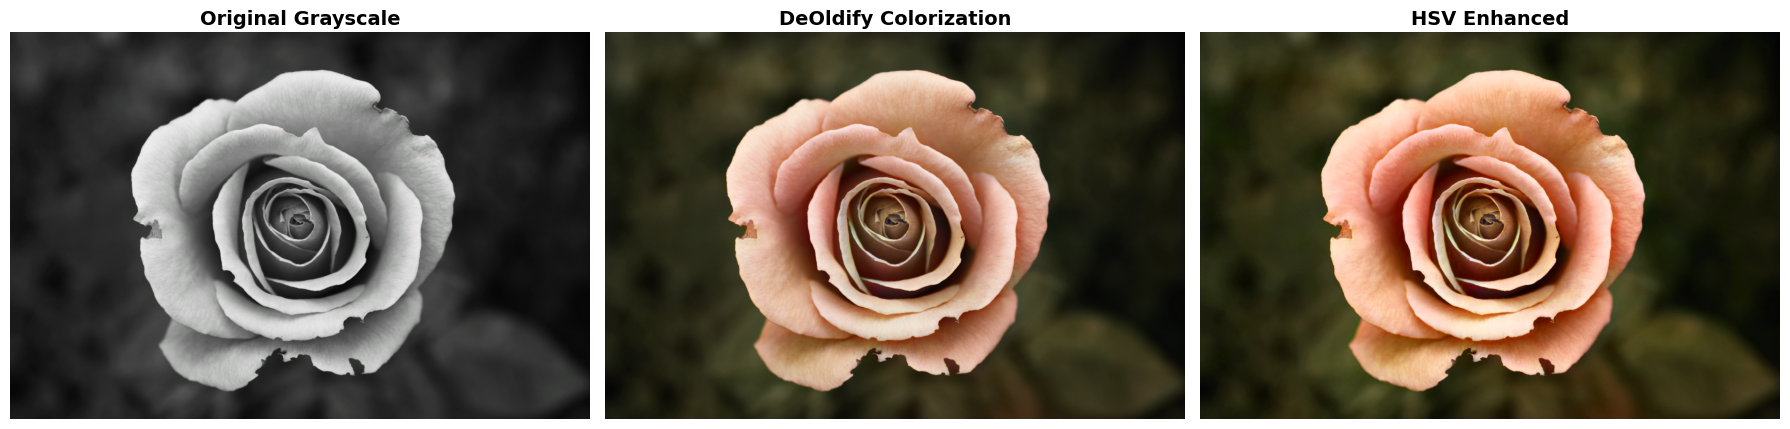

✓ Saved as 'colorized_result.jpg'


In [13]:
image_path = 'old_photo.jpg'  

print("Colorizing your image...")
colorized, enhanced = colorizer.colorize_with_hsv(
    image_path,
    enhance_level='moderate'
)

visualize_comparison(image_path, colorized, enhanced)

enhanced.save('colorized_result.jpg')
print("✓ Saved as 'colorized_result.jpg'")

In [11]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.color import rgb2lab
import numpy as np
import cv2

def evaluate_with_ground_truth(gt_path, pred_path):
    gt = cv2.imread(gt_path)
    pred = cv2.imread(pred_path)

    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)
    pred = cv2.cvtColor(pred, cv2.COLOR_BGR2RGB)

    # Resize if needed
    if gt.shape != pred.shape:
        pred = cv2.resize(pred, (gt.shape[1], gt.shape[0]))

    # SSIM
    ssim_score = ssim(gt, pred, channel_axis=2)

    # PSNR
    psnr_score = psnr(gt, pred)

    # ΔE (color difference)
    lab_gt = rgb2lab(gt)
    lab_pred = rgb2lab(pred)
    delta_e = np.mean(np.linalg.norm(lab_gt - lab_pred, axis=2))

    return {
        "SSIM": ssim_score,
        "PSNR": psnr_score,
        "DeltaE": delta_e
    }


In [12]:
from pathlib import Path

gray_dir = Path("dataset/data/Flowers/flowers_grey")
color_dir = Path("dataset/data/Flowers/flowers_colour")

results = []

for gray_file in gray_dir.iterdir():
    gt_file = color_dir / gray_file.name  # match by file name

    if gt_file.exists():
        # colorize with pipeline
        colorized = colorizer.colorize_image(str(gray_file))
        colorized.save("temp_pred.jpg")

        # evaluate
        metrics = evaluate_with_ground_truth(str(gt_file), "temp_pred.jpg")
        results.append(metrics)

# compute averages
avg_ssim = sum(r["SSIM"] for r in results) / len(results)
avg_psnr = sum(r["PSNR"] for r in results) / len(results)
avg_deltae = sum(r["DeltaE"] for r in results) / len(results)

print(f"Average SSIM: {avg_ssim:.4f}")
print(f"Average PSNR: {avg_psnr:.4f}")
print(f"Average ΔE: {avg_deltae:.4f}")



Colorizing: dataset\data\Flowers\flowers_grey\0001.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0002.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0003.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0004.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0005.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0006.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0007.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0008.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0009.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0010.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0011.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0012.png
Render factor: 35

Colorizing: dataset\data\Flowers\flowers_grey\0013.png
Render factor: 35

Colorizing: dataset\data\Flowers\flow

In [15]:

!pip install gradio
import gradio as gr
import tempfile
import os

colorizer = DeOldifyColorizer(render_factor=35, artistic=True)

def colorize_ui(image, enhance_level):
    """
    image: PIL Image from Gradio
    enhance_level: 'subtle' | 'moderate' | 'strong'
    """
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
        image.save(tmp.name)
        input_path = tmp.name

    _, enhanced = colorizer.colorize_with_hsv(
        image_path=input_path,
        enhance_level=enhance_level
    )

    os.remove(input_path)

    return enhanced


Initializing DeOldify (Artistic mode)...
Using device: 99
DeOldify ready!


In [19]:
# ============================================================================
# USER INTERFACE WEB
# ============================================================================

interface = gr.Interface(
    fn=colorize_ui,
    inputs=[
        gr.Image(type="pil", label="Upload Grayscale Image"),
        gr.Dropdown(
            choices=["subtle", "moderate", "strong"],
            value="moderate",
            label="HSV Enhancement Level"
        )
    ],
    outputs=gr.Image(type="pil", label="Colorized Result"),
    title="🖼️ Image Colorization using DeOldify + HSV",
    description="Upload a grayscale image and get a colorized version enhanced using HSV adjustments.",
)

interface.launch()


* Running on local URL:  http://127.0.0.1:7862
HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
HTTP Request: GET http://127.0.0.1:7862/gradio_api/startup-events "HTTP/1.1 200 OK"
HTTP Request: HEAD http://127.0.0.1:7862/ "HTTP/1.1 200 OK"
* To create a public link, set `share=True` in `launch()`.


HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry "HTTP/1.1 200 OK"
HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
